# ELG 5214 Homework 2


In [90]:
!pip -q install "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip -q install flax optax gymnasium matplotlib

In [91]:
import os
os.environ["JAX_PLATFORMS"] = "gpu"

from functools import partial

import math
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

import jax
import jax.numpy as jnp
import optax
from flax import linen as nn

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())


JAX version: 0.7.2
Devices: [CudaDevice(id=0)]


In [92]:
def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)

NUM_EPISODES = 40
MAX_STEPS = 20
SEEDS = list(range(5))
LEARNING_RATES = [1e-3, 1e-2, 1e-1]
GAMMAS = [0.90, 0.99]

ACTION_NAMES = {
    0: "↑",
    1: "→",
    2: "↓",
    3: "←"
}

In [93]:
class GridWorldEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, slip_prob=0.15, max_steps=60):
        super().__init__()
        self.rows = 5
        self.cols = 5
        self.start_pos = (0, 0)
        self.goal_pos = (4, 4)
        self.obstacles = {(1, 1), (1, 2), (1, 3), (3, 1), (3, 3)}
        self.bad_cells = {(0, 4), (4, 0)}
        self.slip_prob = slip_prob
        self.max_steps = max_steps

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(2,), dtype=np.float32
        )

        self.action_to_delta = {
            0: np.array([-1, 0]),  # up
            1: np.array([0, 1]),   # right
            2: np.array([1, 0]),   # down
            3: np.array([0, -1])   # left
        }

        self.agent_pos = None
        self.steps = 0

    def _get_obs(self):
        obs = np.array(
            [self.agent_pos[0] / (self.rows - 1), self.agent_pos[1] / (self.cols - 1)],
            dtype=np.float32
        )
        return jnp.asarray(obs)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = np.array(self.start_pos, dtype=np.int32)
        self.steps = 0
        return self._get_obs(), {}

    def step(self, action):
        self.steps += 1


        if np.random.rand() < self.slip_prob:
            action = self.action_space.sample()

        proposed = self.agent_pos + self.action_to_delta[int(action)]
        r = int(np.clip(proposed[0], 0, self.rows - 1))
        c = int(np.clip(proposed[1], 0, self.cols - 1))


        if (r, c) not in self.obstacles:
            self.agent_pos = np.array([r, c], dtype=np.int32)

        pos_tuple = tuple(self.agent_pos.tolist())

        reward = -0.1
        terminated = False
        truncated = False

        if pos_tuple in self.bad_cells:
            reward = -1.0

        if pos_tuple == self.goal_pos:
            reward = 10.0
            terminated = True

        if self.steps >= self.max_steps:
            truncated = True

        return self._get_obs(), jnp.asarray(reward, dtype=jnp.float32), terminated, truncated, {}

    def render(self):
        grid = np.full((self.rows, self.cols), ".", dtype=object)
        for r, c in self.obstacles:
            grid[r, c] = "#"
        for r, c in self.bad_cells:
            grid[r, c] = "X"
        gr, gc = self.goal_pos
        grid[gr, gc] = "G"
        ar, ac = self.agent_pos
        grid[ar, ac] = "A"
        print("\n".join(" ".join(row) for row in grid))

In [94]:
env = GridWorldEnv()
obs, _ = env.reset()
print("Initial obs:", obs)
env.render()

Initial obs: [0. 0.]
A . . . X
. # # # .
. . . . .
. # . # .
X . . . G


In [95]:
class ReplayBuffer:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, done):
        self.buffer.append((
            np.array(obs, dtype=np.float32),
            int(action),
            float(reward),
            np.array(next_obs, dtype=np.float32),
            float(done)
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (
            jnp.asarray(np.array(obs), dtype=jnp.float32),
            jnp.asarray(np.array(actions), dtype=jnp.int32),
            jnp.asarray(np.array(rewards), dtype=jnp.float32),
            jnp.asarray(np.array(next_obs), dtype=jnp.float32),
            jnp.asarray(np.array(dones), dtype=jnp.float32),
        )

    def __len__(self):
        return len(self.buffer)

In [96]:
from functools import partial

class QNetwork(nn.Module):
    n_actions: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(32)(x)
        x = nn.relu(x)
        x = nn.Dense(32)(x)
        x = nn.relu(x)
        x = nn.Dense(self.n_actions)(x)
        return x


@partial(jax.jit, static_argnames=["model", "optimizer"])
def dqn_update_step(params, target_params, opt_state, obs, actions, rewards, next_obs, dones, gamma, model, optimizer):
    def loss_fn(p):
        q_values = model.apply(p, obs)
        chosen_q = jnp.take_along_axis(q_values, actions[:, None], axis=1).squeeze()

        next_q = model.apply(target_params, next_obs)
        max_next_q = jnp.max(next_q, axis=1)

        targets = rewards + gamma * (1.0 - dones) * max_next_q
        loss = jnp.mean((chosen_q - targets) ** 2)
        return loss

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def epsilon_greedy_action(params, model, obs, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(4)
    q_values = model.apply(params, jnp.asarray(obs)[None, :])[0]
    return int(jnp.argmax(q_values))

In [97]:
from functools import partial

class PolicyNetwork(nn.Module):
    n_actions: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(32)(x)
        x = nn.tanh(x)
        x = nn.Dense(32)(x)
        x = nn.tanh(x)
        x = nn.Dense(self.n_actions)(x)
        return x

def sample_action_from_policy(params, model, obs, key):
    logits = model.apply(params, jnp.asarray(obs)[None, :])[0]
    action = jax.random.categorical(key, logits)
    return int(action), logits

def compute_discounted_returns(rewards, gamma):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = float(r) + gamma * G
        returns.append(G)
    returns.reverse()
    returns = np.array(returns, dtype=np.float32)
    if returns.std() > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return jnp.asarray(returns, dtype=jnp.float32)

@partial(jax.jit, static_argnames=["model", "optimizer"])
def reinforce_update_step(params, opt_state, obs, actions, returns, model, optimizer):
    def loss_fn(p):
        logits = model.apply(p, obs)
        log_probs = jax.nn.log_softmax(logits, axis=1)
        selected_log_probs = jnp.take_along_axis(log_probs, actions[:, None], axis=1).squeeze()
        loss = -jnp.mean(selected_log_probs * returns)
        return loss

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [98]:
def train_random(seed, num_episodes=NUM_EPISODES):
    set_all_seeds(seed)
    env = GridWorldEnv(max_steps=MAX_STEPS)
    rewards_per_episode = []

    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0

        while not done:
            action = env.action_space.sample()
            next_obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            obs = next_obs
            done = terminated or truncated

        rewards_per_episode.append(total_reward)

    return np.array(rewards_per_episode, dtype=np.float32)

In [99]:
def train_dqn(seed, lr, gamma, num_episodes=NUM_EPISODES):
    set_all_seeds(seed)
    env = GridWorldEnv(max_steps=MAX_STEPS)

    model = QNetwork(n_actions=4)
    dummy_obs = jnp.zeros((1, 2), dtype=jnp.float32)

    key = jax.random.PRNGKey(seed)
    params = model.init(key, dummy_obs)
    target_params = params

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)

    replay_buffer = ReplayBuffer(capacity=5000)

    rewards_per_episode = []
    losses = []

    epsilon_start = 1.0
    epsilon_end = 0.05
    epsilon_decay_episodes = int(0.7 * num_episodes)

    batch_size = 64
    target_update_freq = 50
    global_step = 0

    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0

        epsilon = max(
            epsilon_end,
            epsilon_start - (epsilon_start - epsilon_end) * (ep / max(1, epsilon_decay_episodes))
        )

        while not done:
            action = epsilon_greedy_action(params, model, obs, epsilon)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done_flag = float(terminated or truncated)

            replay_buffer.add(obs, action, reward, next_obs, done_flag)
            total_reward += float(reward)
            obs = next_obs
            done = terminated or truncated
            global_step += 1

            if len(replay_buffer) >= batch_size:
                batch = replay_buffer.sample(batch_size)
                params, opt_state, loss = dqn_update_step(
                    params, target_params, opt_state,
                    batch[0], batch[1], batch[2], batch[3], batch[4],
                    gamma, model, optimizer
                )
                losses.append(float(loss))

            if global_step % target_update_freq == 0:
                target_params = params

        rewards_per_episode.append(total_reward)

    return {
        "rewards": np.array(rewards_per_episode, dtype=np.float32),
        "params": params,
        "model": model,
        "losses": np.array(losses, dtype=np.float32)
    }

In [100]:
def train_reinforce(seed, lr, gamma, num_episodes=NUM_EPISODES):
    set_all_seeds(seed)
    env = GridWorldEnv(max_steps=MAX_STEPS)

    model = PolicyNetwork(n_actions=4)
    dummy_obs = jnp.zeros((1, 2), dtype=jnp.float32)

    key = jax.random.PRNGKey(seed)
    params = model.init(key, dummy_obs)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)

    rewards_per_episode = []
    losses = []

    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0

        traj_obs = []
        traj_actions = []
        traj_rewards = []

        while not done:
            key, subkey = jax.random.split(key)
            action, logits = sample_action_from_policy(params, model, obs, subkey)
            next_obs, reward, terminated, truncated, _ = env.step(action)

            traj_obs.append(np.array(obs, dtype=np.float32))
            traj_actions.append(int(action))
            traj_rewards.append(float(reward))

            total_reward += float(reward)
            obs = next_obs
            done = terminated or truncated

        returns = compute_discounted_returns(traj_rewards, gamma)
        obs_batch = jnp.asarray(np.array(traj_obs), dtype=jnp.float32)
        action_batch = jnp.asarray(np.array(traj_actions), dtype=jnp.int32)

        params, opt_state, loss = reinforce_update_step(
            params, opt_state, obs_batch, action_batch, returns, model, optimizer
        )
        losses.append(float(loss))
        rewards_per_episode.append(total_reward)

    return {
        "rewards": np.array(rewards_per_episode, dtype=np.float32),
        "params": params,
        "model": model,
        "losses": np.array(losses, dtype=np.float32)
    }

In [101]:
results = {
    "Random": {},
    "DQN": {},
    "REINFORCE": {}
}

random_runs = []
for seed in SEEDS:
    random_runs.append(train_random(seed))
results["Random"]["baseline"] = np.stack(random_runs)

for lr in LEARNING_RATES:
    for gamma in GAMMAS:
        key_name = f"lr={lr}_gamma={gamma}"

        dqn_runs = []
        dqn_final_models = []
        for seed in SEEDS:
            out = train_dqn(seed, lr, gamma)
            dqn_runs.append(out["rewards"])
            dqn_final_models.append((out["params"], out["model"]))
        results["DQN"][key_name] = {
            "runs": np.stack(dqn_runs),
            "models": dqn_final_models
        }

        reinforce_runs = []
        reinforce_final_models = []
        for seed in SEEDS:
            out = train_reinforce(seed, lr, gamma)
            reinforce_runs.append(out["rewards"])
            reinforce_final_models.append((out["params"], out["model"]))
        results["REINFORCE"][key_name] = {
            "runs": np.stack(reinforce_runs),
            "models": reinforce_final_models
        }

print("Finished all runs.")

Finished all runs.


In [102]:
def select_best_setting(algo_dict):
    best_name = None
    best_score = -1e9

    for name, payload in algo_dict.items():
        runs = payload["runs"]
        score = runs[:, -50:].mean()
        if score > best_score:
            best_score = score
            best_name = name

    return best_name, best_score

best_dqn_name, best_dqn_score = select_best_setting(results["DQN"])
best_reinforce_name, best_reinforce_score = select_best_setting(results["REINFORCE"])

print("Best DQN:", best_dqn_name, "score =", best_dqn_score)
print("Best REINFORCE:", best_reinforce_name, "score =", best_reinforce_score)

Best DQN: lr=0.01_gamma=0.99 score = 0.4685
Best REINFORCE: lr=0.01_gamma=0.99 score = -1.9654999


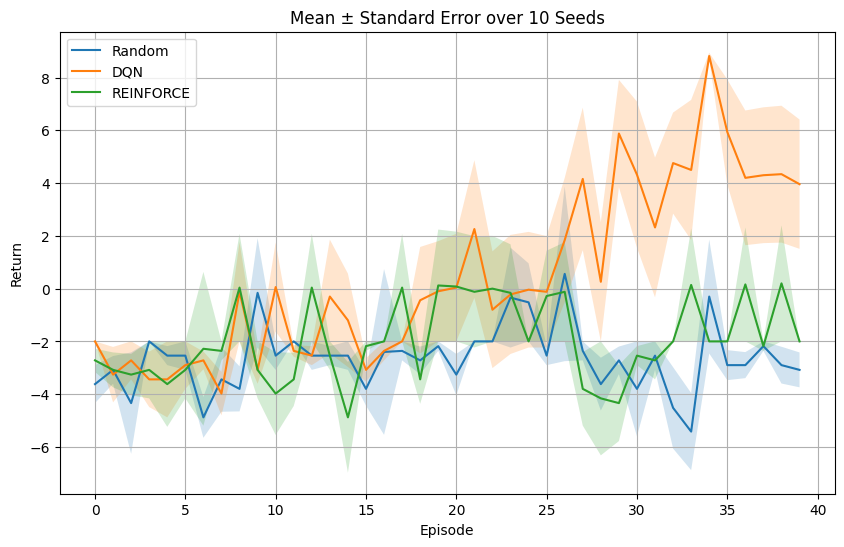

In [103]:
def mean_and_se(x):
    mean = x.mean(axis=0)
    se = x.std(axis=0, ddof=1) / np.sqrt(x.shape[0])
    return mean, se

random_runs = results["Random"]["baseline"]
dqn_runs = results["DQN"][best_dqn_name]["runs"]
reinforce_runs = results["REINFORCE"][best_reinforce_name]["runs"]

plt.figure(figsize=(10, 6))

for label, runs in [
    ("Random", random_runs),
    ("DQN", dqn_runs),
    ("REINFORCE", reinforce_runs)
]:
    mean, se = mean_and_se(runs)
    x = np.arange(len(mean))
    plt.plot(x, mean, label=label)
    plt.fill_between(x, mean - se, mean + se, alpha=0.2)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Mean ± Standard Error over 10 Seeds")
plt.legend()
plt.grid(True)
plt.show()

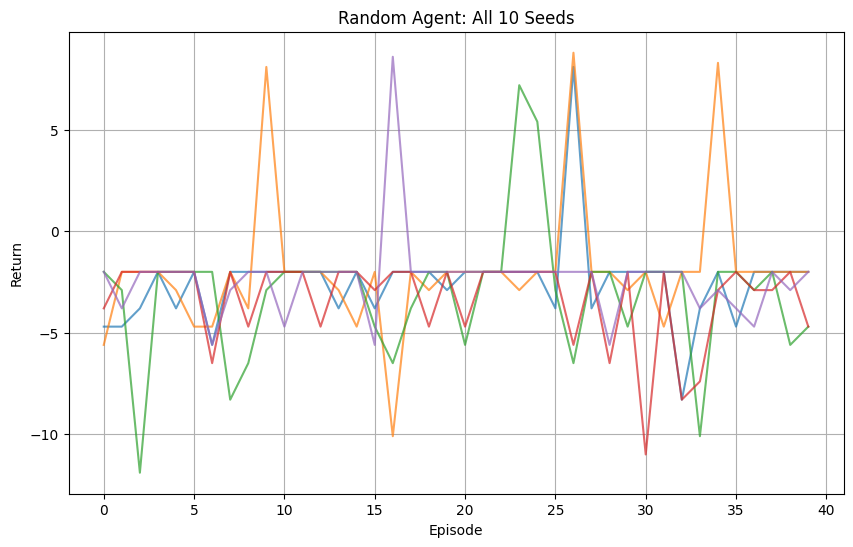

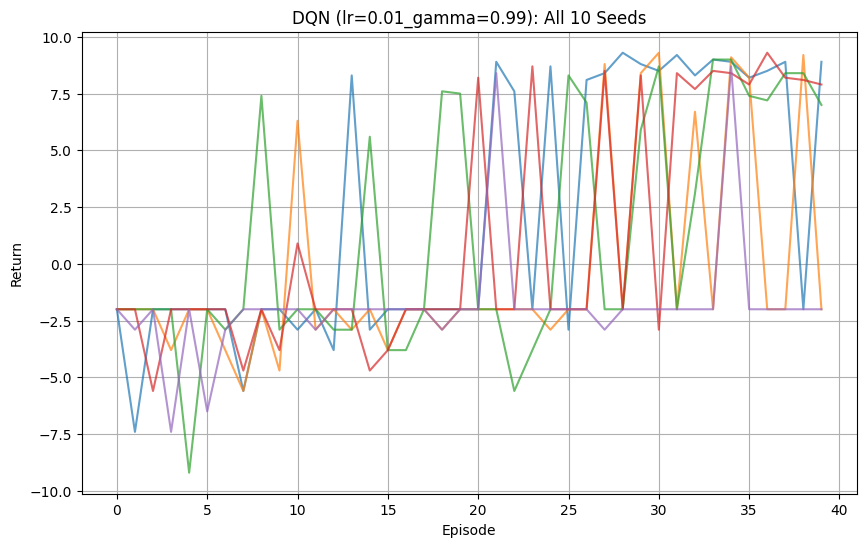

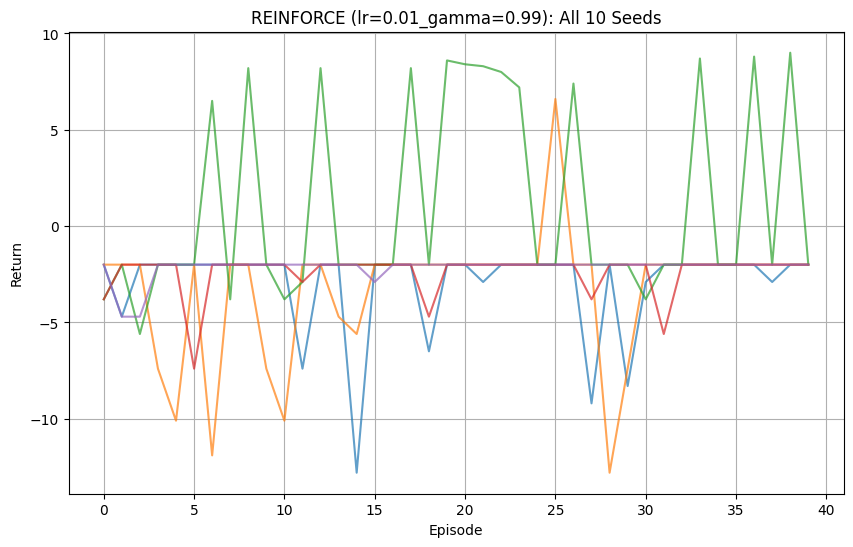

In [104]:
def plot_all_runs(runs, title):
    plt.figure(figsize=(10, 6))
    for i in range(runs.shape[0]):
        plt.plot(runs[i], alpha=0.7, label=f"Seed {i}" if i < 3 else None)
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_all_runs(random_runs, "Random Agent: All 10 Seeds")
plot_all_runs(dqn_runs, f"DQN ({best_dqn_name}): All 10 Seeds")
plot_all_runs(reinforce_runs, f"REINFORCE ({best_reinforce_name}): All 10 Seeds")

In [105]:
def summarize_hyperparams(algo_name, algo_dict):
    rows = []
    for name, payload in algo_dict.items():
        runs = payload["runs"]
        final_mean = runs[:, -50:].mean()
        final_std = runs[:, -50:].mean(axis=1).std()
        rows.append((name, final_mean, final_std))
    rows = sorted(rows, key=lambda x: x[1], reverse=True)

    print(f"\n{algo_name} hyperparameter summary")
    print("-" * 60)
    for name, final_mean, final_std in rows:
        print(f"{name:25s}  final_mean={final_mean:8.3f}  seed_std={final_std:8.3f}")

summarize_hyperparams("DQN", results["DQN"])
summarize_hyperparams("REINFORCE", results["REINFORCE"])


DQN hyperparameter summary
------------------------------------------------------------
lr=0.01_gamma=0.99         final_mean=   0.468  seed_std=   1.402
lr=0.01_gamma=0.9          final_mean=  -0.501  seed_std=   1.898
lr=0.001_gamma=0.99        final_mean=  -0.623  seed_std=   1.185
lr=0.001_gamma=0.9         final_mean=  -1.829  seed_std=   0.635
lr=0.1_gamma=0.99          final_mean=  -1.967  seed_std=   1.014
lr=0.1_gamma=0.9           final_mean=  -2.925  seed_std=   0.101

REINFORCE hyperparameter summary
------------------------------------------------------------
lr=0.01_gamma=0.99         final_mean=  -1.965  seed_std=   1.533
lr=0.01_gamma=0.9          final_mean=  -2.160  seed_std=   0.175
lr=0.001_gamma=0.9         final_mean=  -2.611  seed_std=   0.458
lr=0.001_gamma=0.99        final_mean=  -2.634  seed_std=   0.394
lr=0.1_gamma=0.99          final_mean=  -4.247  seed_std=   4.247
lr=0.1_gamma=0.9           final_mean=  -5.382  seed_std=   3.790


In [106]:
def get_all_states(env):
    states = []
    coords = []
    for r in range(env.rows):
        for c in range(env.cols):
            if (r, c) in env.obstacles:
                continue
            obs = np.array([r / (env.rows - 1), c / (env.cols - 1)], dtype=np.float32)
            states.append(obs)
            coords.append((r, c))
    return np.array(states, dtype=np.float32), coords

def visualize_dqn_policy(params, model, env, title="DQN Policy"):
    states, coords = get_all_states(env)
    q_values = model.apply(params, jnp.asarray(states))
    best_actions = np.array(jnp.argmax(q_values, axis=1))
    state_values = np.array(jnp.max(q_values, axis=1))

    arrow_grid = np.full((env.rows, env.cols), "", dtype=object)
    value_grid = np.full((env.rows, env.cols), np.nan, dtype=np.float32)

    for (r, c), a, v in zip(coords, best_actions, state_values):
        arrow_grid[r, c] = ACTION_NAMES[int(a)]
        value_grid[r, c] = float(v)

    for r, c in env.obstacles:
        arrow_grid[r, c] = "#"
    arrow_grid[env.goal_pos] = "G"

    plt.figure(figsize=(6, 6))
    plt.imshow(value_grid, interpolation="nearest")
    plt.colorbar(label="max Q(s,a)")
    plt.title(title)
    for r in range(env.rows):
        for c in range(env.cols):
            txt = arrow_grid[r, c]
            if txt != "":
                plt.text(c, r, txt, ha="center", va="center", color="white", fontsize=14)
    plt.xticks(range(env.cols))
    plt.yticks(range(env.rows))
    plt.show()

def visualize_reinforce_policy(params, model, env, title="REINFORCE Policy"):
    states, coords = get_all_states(env)
    logits = model.apply(params, jnp.asarray(states))
    probs = jax.nn.softmax(logits, axis=1)
    best_actions = np.array(jnp.argmax(probs, axis=1))
    confidences = np.array(jnp.max(probs, axis=1))

    arrow_grid = np.full((env.rows, env.cols), "", dtype=object)
    conf_grid = np.full((env.rows, env.cols), np.nan, dtype=np.float32)

    for (r, c), a, conf in zip(coords, best_actions, confidences):
        arrow_grid[r, c] = ACTION_NAMES[int(a)]
        conf_grid[r, c] = float(conf)

    for r, c in env.obstacles:
        arrow_grid[r, c] = "#"
    arrow_grid[env.goal_pos] = "G"

    plt.figure(figsize=(6, 6))
    plt.imshow(conf_grid, interpolation="nearest")
    plt.colorbar(label="max policy probability")
    plt.title(title)
    for r in range(env.rows):
        for c in range(env.cols):
            txt = arrow_grid[r, c]
            if txt != "":
                plt.text(c, r, txt, ha="center", va="center", color="white", fontsize=14)
    plt.xticks(range(env.cols))
    plt.yticks(range(env.rows))
    plt.show()

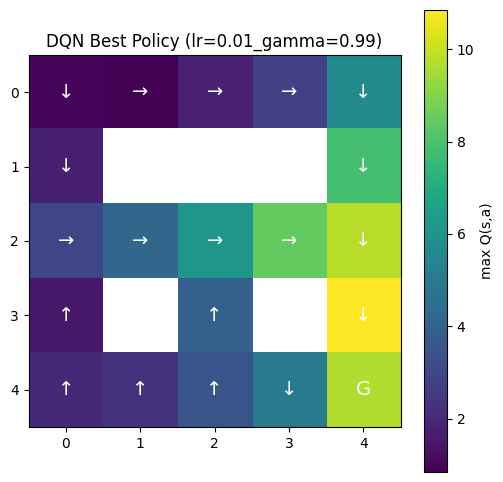

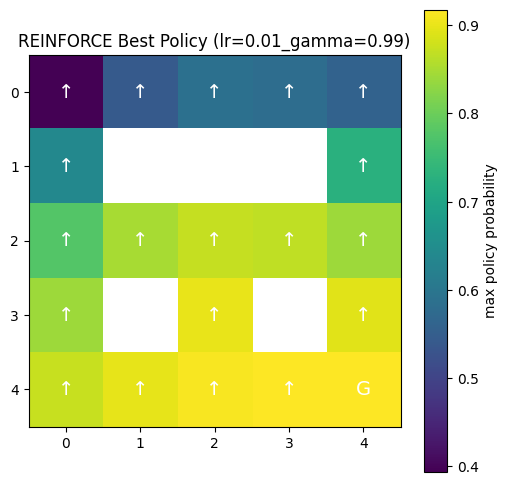

In [107]:
env_vis = GridWorldEnv()

best_dqn_params, best_dqn_model = results["DQN"][best_dqn_name]["models"][0]
best_reinforce_params, best_reinforce_model = results["REINFORCE"][best_reinforce_name]["models"][0]

visualize_dqn_policy(best_dqn_params, best_dqn_model, env_vis, title=f"DQN Best Policy ({best_dqn_name})")
visualize_reinforce_policy(best_reinforce_params, best_reinforce_model, env_vis, title=f"REINFORCE Best Policy ({best_reinforce_name})")

In [108]:
def final_stats(runs):
    last50 = runs[:, -50:].mean(axis=1)
    return last50.mean(), last50.std(ddof=1)

print("Final performance over last 50 episodes")
print("-" * 50)

rand_mean, rand_std = final_stats(random_runs)
dqn_mean, dqn_std = final_stats(dqn_runs)
rein_mean, rein_std = final_stats(reinforce_runs)

print(f"Random     mean={rand_mean:.3f}, std={rand_std:.3f}")
print(f"DQN        mean={dqn_mean:.3f}, std={dqn_std:.3f}")
print(f"REINFORCE  mean={rein_mean:.3f}, std={rein_std:.3f}")

Final performance over last 50 episodes
--------------------------------------------------
Random     mean=-2.634, std=0.547
DQN        mean=0.469, std=1.568
REINFORCE  mean=-1.966, std=1.714
